In [1]:
# 第1格：v16新批次；固定旧批20概念，逐题接Z-Image作答、GPT-6 xhigh联合评审。
# RUN_PIPELINE=False只加载配置；True通过正式CLI后台提交，前台也使用相同config → run_pipeline。
# 出题、生图、评审最多各20次；失败保留，不替换概念。旧run及其18题、2失败保持历史。
# Codex用原生文件工具读取固定快照，并按需live检索；定义保留，材料不限定考点。
import asyncio
import subprocess
from datetime import datetime, timezone
import json
import os
import sys
from pathlib import Path
from IPython.display import display

PROJECT = Path('/yzp/zhaozy/yangzepeng/0905/demiwtg')
DATA_ROOT = PROJECT.parent
for path in (PROJECT, DATA_ROOT / 'demiflow'):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))
os.environ['DEMIWTG_DATASETS_ROOT'] = str(DATA_ROOT)
# 本机4001网关已验证无需客户端密钥；平台客户端要求非空值，仅补本地占位，不覆盖已有配置。
os.environ.setdefault('MODELHUB_API_KEY', 'anything')
from benchmark.t2i.v2 import t2i_v2_benchmark_pipeline as pipeline


RUN_ID = 'ready_positive20_taxonomyv8_codex_v16_probe_20261004'
CONFIG_PATH = PROJECT / 'benchmark/t2i/v2/runs' / RUN_ID / 'config.json'
# 固定来源清单与完整参数保存在同一config.json；CLI --config 和后台执行共用此文件。
PARAMETERS = json.loads(CONFIG_PATH.read_text())
PARAMETERS.update(
    sample_size=20, sample_seed=20261003, min_positive_images=5, sampling_depth=2,
    max_reference_images=5, authoring_variants=None, authoring_variant='with_positive_images',
    agent_config=str(PROJECT / 'benchmark/t2i/v2/prompts/agent_codex.yaml'),
    concurrency=4, queue_depth=1, max_calls=20, through='probe',
    probe={
        'revision':'zimage-turbo-fullgpu-dp2-8steps-guidance1-v1',
        'endpoints':['http://127.0.0.1:8003/v1','http://127.0.0.1:8004/v1'],
        'image_size':'1024x1024', 'steps':8, 'run_seed':20261003,
        'concurrency':2, 'queue_depth':1, 'max_generation_calls':20,
        'review_concurrency':2, 'review_queue_depth':1, 'max_review_calls':20,
        'review_timeout_s':600, 'review_max_output_tokens':8192,
    },
)
RUN_DIR = Path(PARAMETERS['run'])
CONFIG = pipeline.config(**PARAMETERS)
# 防止共享工作区中的旧prompt覆盖：提交前核对本批约定。
import yaml
AGENT = yaml.safe_load(Path(CONFIG['agent_config']).read_text())
assert AGENT['tasks']['design_question']['version'] == 't2i-v2-independent-materials-16'
assert (CONFIG['model'], CONFIG['reasoning_effort'], CONFIG['codex_web_search']) == ('gpt-6-astra', 'xhigh', 'live')
assert '概念说明中提到的具体特征、实例或任务建议仅供理解，不限定考点或出题方向；请在保留概念身份和必要范围的前提下，按下文质量标准独立设计任务。' in AGENT['tasks']['design_question']['template']
assert CONFIG['max_calls'] == CONFIG['probe']['max_generation_calls'] == CONFIG['probe']['max_review_calls'] == 20
assert AGENT['options']['codex_agent']['max_message_bytes'] is None
RUN_PIPELINE = False  # 后台已启动时只运行第2格，避免重复提交。
BACKGROUND = True
print('固定概念来源：', CONFIG['cohort_source'] or CONFIG['concept_audit_source'])
print('固定图审快照：', len(CONFIG['positive_review_sources'] or []))
print('抽样分类摘要：', CONFIG['sampling_taxonomy_source'])
print('Agent配置入口：', CONFIG['agent_config'])
print('Codex模型：', CONFIG['model'], '；推理强度：', CONFIG['reasoning_effort'], '；本轮新会话上限：', CONFIG['max_calls'], '；原生检索：', CONFIG['codex_web_search'])
print('仅有正例图版20个概念，出题后逐题探测；作答模型只收题面，不收考点、判据或作者正例。')
print('评审：malasci/gpt-6-astra，reasoning_effort=xhigh；一次调用完成考点评审和分类依据。')
print('生图服务需已在配置端点启动；本notebook不自动启动GPU服务。', CONFIG['probe'])
print('Codex内部模型轮数、token和检索次数不受max_calls限制；整会话超时600秒。')
if RUN_PIPELINE:
    if BACKGROUND:
        # 只提交同一个正式CLI；运行锁和模型预算由平台维护，不在notebook另建调度流程。
        PROCESS_PATH = CONFIG_PATH.parent / 'process.json'
        previous = json.loads(PROCESS_PATH.read_text()) if PROCESS_PATH.exists() else {}
        previous_proc = Path('/proc') / str(previous.get('pid', 0))
        if previous_proc.exists() and previous.get('process_start_ticks') == previous_proc.joinpath('stat').read_text().rsplit(')', 1)[1].split()[19]:
            raise RuntimeError(f"本轮后台进程仍在运行：PID {previous['pid']}；请直接运行第2格。")
        CONFIG_PATH.write_text(json.dumps(PARAMETERS, ensure_ascii=False, indent=2) + '\n')
        started = datetime.now(timezone.utc)
        LOG_PATH = CONFIG_PATH.parent / ('probe_' + started.strftime('%Y%m%dT%H%M%SZ') + '.log')
        command = [sys.executable, '-u', '-m', 'benchmark.t2i.v2.t2i_v2_benchmark_pipeline', '--config', str(CONFIG_PATH)]
        with LOG_PATH.open('ab') as output:
            process = subprocess.Popen(command, cwd=PROJECT,
                env={**os.environ, 'PYTHONPATH': os.pathsep.join([str(PROJECT), str(DATA_ROOT / 'demiflow'), os.environ.get('PYTHONPATH', '')])},
                stdin=subprocess.DEVNULL, stdout=output, stderr=subprocess.STDOUT, start_new_session=True)
        receipt = {'pid': process.pid, 'started_at': started.isoformat(), 'config': str(CONFIG_PATH),
                   'log': str(LOG_PATH), 'command': command,
                   'process_start_ticks': Path(f'/proc/{process.pid}/stat').read_text().rsplit(')', 1)[1].split()[19]}
        PROCESS_PATH.write_text(json.dumps(receipt, ensure_ascii=False, indent=2) + '\n')
        display(receipt)
        print('后台已提交；第2格可独立反复运行查看20概念进度、题面、作答图和评审。')
    else:
        state = await asyncio.to_thread(pipeline.run_pipeline, CONFIG)
        display(state)
else:
    print('本格未提交新任务；第2格可独立查看后台进度、已返回题目及已提交结果。')

# 300个名单修订：第一类目标100，当前先纳入全部至少1张正例的85项，优先替换纯第3类。
# 独立run只提交输入；原20个题目/作答/评审仍按上面的RUN_ID查看。
SELECTION_RUN_ID = 'ready_positive300_common100_priority_20261004'
SELECTION_CONFIG_PATH = PROJECT / 'benchmark/t2i/v2/runs' / SELECTION_RUN_ID / 'config.json'
REBUILD_COHORT = False
SELECTION_PARAMETERS = json.loads(SELECTION_CONFIG_PATH.read_text())
SELECTION_CONFIG = pipeline.config(**SELECTION_PARAMETERS)
assert SELECTION_CONFIG['through'] == 'inputs'
display({'300概念名单配置':str(SELECTION_CONFIG_PATH), '修订策略':SELECTION_CONFIG['cohort_revision']})
if REBUILD_COHORT:
    COHORT_STATE = pipeline.run_pipeline(SELECTION_CONFIG)
    display({'已提交名单':COHORT_STATE['inputs'], '替换结果':COHORT_STATE['selection']['revision']})


固定概念来源： {'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/cohort__ready_positive20_taxonomyv8_codex_20261003__with_positive_images.lance', 'version': 1}
固定图审快照： 0
抽样分类摘要： None
Agent配置入口： /yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/prompts/agent_codex.yaml
Codex模型： gpt-6-astra ；推理强度： xhigh ；本轮新会话上限： 20 ；原生检索： live
仅有正例图版20个概念，出题后逐题探测；作答模型只收题面，不收考点、判据或作者正例。
评审：malasci/gpt-6-astra，reasoning_effort=xhigh；一次调用完成考点评审和分类依据。
生图服务需已在配置端点启动；本notebook不自动启动GPU服务。 {'model': 'Z-Image-Turbo', 'endpoints': ['http://127.0.0.1:8003/v1', 'http://127.0.0.1:8004/v1'], 'image_size': '1024x1024', 'steps': 8, 'run_seed': 20261003, 'concurrency': 2, 'queue_depth': 1, 'timeout_s': 600, 'max_image_bytes': 33554432, 'max_generation_calls': 20, 'review_concurrency': 2, 'review_queue_depth': 1, 'max_review_calls': 20, 'review_timeout_s': 600, 'review_max_output_tokens': 8192, 'review_max_context_chars': 60000, 'revision': 'zimage-turbo-fullgpu-dp2-8steps-guidance1-v1'}
Codex内部模型轮数、toke

{'300概念名单配置': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/runs/ready_positive300_common100_priority_20261004/config.json',
 '修订策略': {'base_cohort': {'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/cohort__ready_positive300_taxonomyv8_codex_ab_20261003.lance',
   'version': 1},
  'case_category_sources': [{'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/case_annotation/datasets/classifications__case_annotation_high_l3_random7000_joint_v1_20260929.lance',
    'version': 1,
    'kind': 'classifications'},
   {'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/case_annotation/datasets/adjudications__case_annotation_review_v2_20260929.lance',
    'version': 1,
    'kind': 'adjudications'}],
  'common_limit': 100,
  'min_common_positive_images': 1,
  'common_allow_unassigned_taxonomy': True,
  'image_exclusions': [{'sha256': 'a23dcdeac57ab5af99493054754e05f18a3455b65a9f5ff8f58057e5114ce0e2',
    'reason': '镰刀：PNG 11785x11769，无法在解码前降采样，超过2400万像

[T2I paired] 固定采纳来源={'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/preparation/concepts/datasets/adopted__taxonomy3315_adopted_20261003_v1.lance', 'version': 1}，图审快照=35；门槛=5张，选择=300概念


[T2I cohort revision] 原第一类目标=100，第一类正例下限=1；优先替换纯第3类，全部规则和固定来源保存到修订摘要


[T2I paired] 合格=939，已提交共同输入=300，{'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/cohort__ready_positive300_common100_priority_20261004.lance', 'version': 4}


{'已提交名单': {'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/cohort__ready_positive300_common100_priority_20261004.lance',
  'version': 4},
 '替换结果': {'base_cohort': {'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/cohort__ready_positive300_taxonomyv8_codex_ab_20261003.lance',
   'version': 1},
  'case_category_sources': [{'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/case_annotation/datasets/classifications__case_annotation_high_l3_random7000_joint_v1_20260929.lance',
    'version': 1,
    'kind': 'classifications'},
   {'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/case_annotation/datasets/adjudications__case_annotation_review_v2_20260929.lance',
    'version': 1,
    'kind': 'adjudications'}],
  'common_limit': 100,
  'min_common_positive_images': 1,
  'common_allow_unassigned_taxonomy': True,
  'image_exclusions': [{'sha256': 'a23dcdeac57ab5af99493054754e05f18a3455b65a9f5ff8f58057e5114ce0e2',
    'reason': '镰刀：PNG 117

**300个名单已修订**：第一类目标 100 个，实际 85 个；新增 59 个，替换 59 个。当前只提交名单，尚未启动本300项出题。

{'新名单固定版本': {'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/cohort__ready_positive300_common100_priority_20261004.lance',
  'version': 3},
 '分类挂载待补': ['禁止停车黄网线'],
 '第一类正例下限': 1,
 '待补至目标': 15,
 '技术原因排除的参考图': [{'reason': '镰刀：PNG 11785x11769，无法在解码前降采样，超过2400万像素；只从本轮作者参考图池排除，原审核及图片对象保留。',
   'sha256': 'a23dcdeac57ab5af99493054754e05f18a3455b65a9f5ff8f58057e5114ce0e2'}]}

{'已检查参考图关系': 341, '技术失败': []}

,概念数
原分类,
1,82
1 / 2,2
1 / 3,1
2,212
2 / 3,1
3,2


,selection_rank,concept,原分类,positive_image_count,sampling_category
16,1,摩天大楼上的午餐,2,5,摄影活动与影像
105,2,斗兽棋棋盘,1,8,游戏棋盘与盘面
36,3,泰坦尼克号遗址,2,5,沉船遗址
173,4,爱（罗伯特·印第安纳）,2,8,视觉艺术与图像设计
293,5,老虎栖息地,2,6,生物栖息环境
30,6,那达慕大会,1,9,文化体系与传统
299,7,特洛伊战争传说,1,5,历史与神话叙事
56,8,奥西里斯,2,8,人物、角色与外观
222,9,六股辫,3,5,辫状编织结构
27,10,贴头辫,2,5,发型与造型技法


...

### 提供5张作者正例图

状态：**candidate**；

**题面：** 生成一幅绳线六股辫的编织结构教学示意图，采用各股独立交织的平纹扁辫形式。用彼此容易区分的纯色表示各股，正面展示包含数次重复交织的一段辫体，以及它与尚未编入的全部自由端的连接。编织适当疏松，使股线走向和交叉处的上下关系清晰可辨。

,考点,依据,可观察判据
0,六个独立编织股在辫体与自由端之间保持连续对应。,概念说明明确六股辫由六股材料有序交织形成。实际查阅的 [T. J. Potter《Instructions for a 6-strand Flat Braid》](https://www.seekyee.com/Slings/howtos/6strand1.htm)从左右各三股开始，分别移动单股完成编织，支持本题选择的六股独立交织形式。不同纯色仅用于追踪股线。,应能辨认六个独立自由端，并沿颜色和轮廓将它们分别追踪进同一辫体；六股均参与交织，途中不凭空增加、消失、分叉或合并。仅在末端画出六条线，而辫体实际只有三股，或始终把材料两两并成三束编织，均不符合本题条件。遮挡后走向不能辨认时，属于证据不足。
1,平纹六股扁辫具有连续、可实现的上下交替交织关系。,平纹结构的稳定知识是逐股上下交替。[Paracord Guild《Starting Australian flat braids》](https://www.paracordguild.com/starting-australian-flat-braids/)的六股扁辫示范采用左外股依次从下、上穿行，右外股依次从上、下、上穿行，再重复操作。这支持本题指定的平纹形式，不作为所有六股辫编法的统一规则。,在连续辫体内沿同一股追踪，相邻交叉应呈现压过一股、穿到下一股下方的交替关系；各股斜向交织并在边缘回转，组成统一扁辫。交叉处应能辨认上层股的连续轮廓与下层股的局部遮挡。仅画相交色线而无上下关系、股线互相穿透，或全部同向螺旋绞合，均为实质错误。允许镜像编织、不同配色及合理松紧变化。


**Z-Image 作答：** generated 

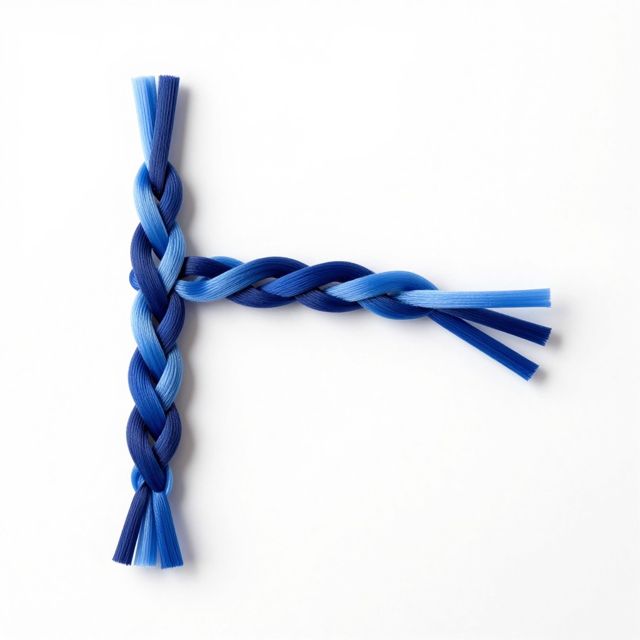

{'task_id': 't2i_99121d327634794c59b8679a1066a8ed5e3375714a83f9850b4e7221d64330b3',
 '生成模型': 'Z-Image-Turbo',
 'seed': 280173676,
 '图像SHA': 'b93bd9698d4d556b1ed6bbae12b3206c0f2dfb0aa5fe23ba020d34f81c15df3a'}

**GPT-6 评审：** reviewed 

{'结论': 'fail',
 '分数（-1=不评分）': 1,
 '原因': '图中主要呈现两段相互垂直、疑似各由少数股线组成的蓝色辫体，在交叉处彼此叠接，未形成可连续追踪的单一六股扁辫。右侧和上下端虽可见若干自由线，但无法对应到同一辫体中的六个独立编织股，且整体不满足题面要求的清晰教学示意结构。',
 '依据': '依据题面要求，六股材料应作为六个独立股线连续进入同一段平纹扁辫，并在交叉处呈可辨认的上下交替关系。图像的颜色和结构不足以支持六股连续对应，且可见的两段交叉构型与单一六股扁辫不符。',
 '错误类型': 'structure_config',
 '本轮评审建议类别': 3}

,考点编号,判断,像素证据,理由
0,1,fail,画面中央是一段竖直蓝色辫体与一段水平蓝色辫体相交；上端、下端和右端虽有若干线束露出，但没有六个彼此区分的自由端能够沿轮廓连续追踪进同一条辫体。,可见结构更像两段独立的蓝色辫体在中部叠接，而不是六个独立股线共同编入一段辫体，因此不满足六股连续对应和全部参与交织的判据。
1,2,fail,局部辫体可见部分上下覆盖和交叉，但在中央交叉处两段结构互相叠接，股线数量、上下关系及边缘回转无法连续贯通；图中也未清楚展示一条具有重复平纹交织的六股扁辫。,局部存在类似编织的遮挡关系不能证明目标结构；由于整体构型不是可连续追踪的单一六股扁辫，无法满足连续、可实现的六股平纹上下交替关系。


{'knowledge_level': 'specialist',
 'common_cn': 'no',
 'visual_support': 'strong',
 'confidence': 'high',
 'reason': '“六股辫”限定了股线数量及其连续交织配置，需辨认六个独立股线、平纹扁辫的上下关系和连接方式，超出普通“辫子”外观即可判断的粒度。其关键特征具有明确的可视化表现，通常可通过结构图或清晰实物图核对。',
 'caveat': '允许镜像、配色和合理松紧变化，但仍需在同一辫体中保持六个独立股线及可追踪的平纹交织关系；仅凭局部遮挡不能确认隐藏的股线对应。',
 'sources': []}

{'生成固定快照': {'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/probe_generations__ready_positive20_taxonomyv8_codex_v16_probe_20261004.lance',
  'version': 9},
 '评审快照': {'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/probe_reviews__ready_positive20_taxonomyv8_codex_v16_probe_20261004.lance',
  'version': 19}}

{'runtime': 'codex',
 '记录轮次或会话数': 1,
 '算子观察数': 0,
 '结果版本': {'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/designs__ready_positive20_taxonomyv8_codex_v16_probe_20261004.lance',
  'version': 21},
 '复用': False}

{'原生检索次数': 2,
 '完整会话日志': {'journal_path': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/calls__ready_positive20_taxonomyv8_codex_v16_probe_20261004.sqlite',
  'request_id': '4937b428c1a6937cc6b9f3f974cb4c6ec854ec5036022bfcefb8a7efc713a092',
  'kind': 'response'}}

### 固定名单绑定的作者正例（实际发送是否成功见设计状态）

作者正例图 1 · SHA `cdc349f58d50`

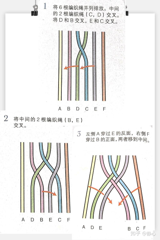

作者正例图 2 · SHA `ccd329a7825c`

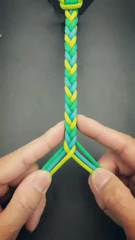

作者正例图 3 · SHA `45ff1da2b584`

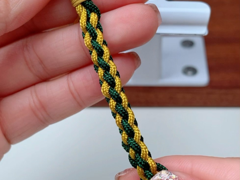

作者正例图 4 · SHA `8d52837a8c45`

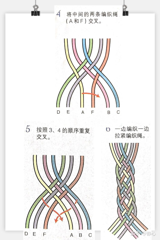

作者正例图 5 · SHA `acd5e3cbb9e2`

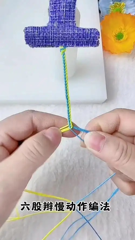

## 19. 动物细胞
分类桶：科学结构与物质概念；审核正例：6 张

**原概念分类：** 2 · 有显著的视觉特征

定义：“动物细胞”指动物体内的动物细胞这一生物学类别，通常包括具有细胞膜、细胞质、细胞核及多种膜性细胞器的真核细胞；该名称本身没有限定具体组织、物种、形态或发育阶段，因此也包括具有特化结构或在发育中缺少某些典型结构的细胞。用于教学图示时，通常可选取一个典型的有核动物细胞模型，但模型不能代替整个类别。

### 提供5张作者正例图

状态：**candidate**；

**题面：** 生成一幅典型动物体细胞在有丝分裂末期进行胞质分裂的教学示意图，表现两个子核已经重建、胞质仍相连且正在分开的时刻。展示细胞整体外形，并通过局部剖视或透明表现，清楚呈现驱动胞质分裂的主要结构及其与细胞膜、分裂部位的空间关系。

,考点,依据,可观察判据
0,动物细胞胞质分裂中，收缩环与细胞膜内陷及胞质连接的结构关系。,依据稳定的细胞生物学知识：典型动物体细胞通过分裂沟内陷完成胞质分裂。由肌动蛋白和肌球蛋白组成的收缩环位于分裂面附近、紧贴细胞膜胞质侧的皮层，环绕细胞并收缩，使该处细胞膜向内凹陷。在题面指定的阶段，两侧各有重建的子核，胞质尚保持连接；植物细胞由中央形成细胞板的方式不适用于此任务。,细胞应在两个子核之间出现由表面向内凹入的分裂沟，两侧胞质仍通过收窄部位相连。收缩环应沿这一部位的周向分布，位于细胞膜内侧，并与膜的内陷位置对应；剖视可只显示部分环，但须能辨认其环绕关系。将收缩环画在细胞外、围住子核或横穿胞质成为实心隔板，以及用中央细胞板向外扩展代替分裂沟，均为实质错误。仅有文字标签而无对应结构不足以确认；不要求两侧大小完全相等或逐根表现蛋白纤维。


**Z-Image 作答：** generated 

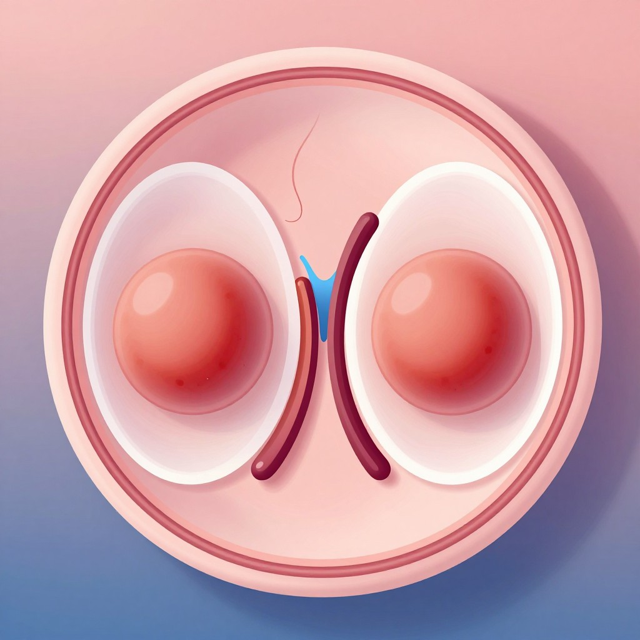

{'task_id': 't2i_69f101b39c1272a718885ea0cba3b98ed6056a2975891100fbe9edaaab6b621a',
 '生成模型': 'Z-Image-Turbo',
 'seed': 443421698,
 '图像SHA': '2df4daae10455063ae8dfdf1e64f3540303c51a2c98e80f0bd36e2776b0e3436'}

**GPT-6 评审：** reviewed 

{'结论': 'fail',
 '分数（-1=不评分）': 2,
 '原因': '图中虽有左右两个核样结构，但完整外轮廓近圆形，未呈现两个子核之间由表面内陷形成的分裂沟和收窄的胞质连接。中央两条游离弧状结构也未显示贴膜、环绕分裂部位的收缩环关系，核心结构要求不成立。',
 '依据': '采用典型动物体细胞胞质分裂的稳定知识：收缩环位于分裂面附近的细胞膜胞质侧，沿周向收缩并推动分裂沟内陷；指定阶段应有两个重建子核及尚未断开的胞质连接。给定判据适用于题面，不要求逐根绘出蛋白纤维或完全对称的子细胞。',
 '错误类型': 'structure_config',
 '本轮评审建议类别': 3}

,考点编号,判断,像素证据,理由
0,1,fail,图中左右各有一个红色圆形核样结构，外有浅色椭圆区域；细胞外围的粉红色边界完整可见，整体近圆形，上下两端均未在两核之间向内凹陷。两核之间画有两条深红色纵向弧条及一小片蓝色结构，弧条与外围膜之间明显有间隔，未形成贴着收窄膜部位的周向环绕关系。,两核样结构仅支持部分阶段特征，不能替代胞质分裂的关键结构。外边界充分展示却没有分裂沟或细腰，中央弧条也没有与膜内陷对应，因而不是由遮挡导致无法确认，而是可见结构与核心判据冲突。


{'knowledge_level': 'specialist',
 'common_cn': 'no',
 'visual_support': 'strong',
 'confidence': 'high',
 'reason': '动物细胞这一上位概念较常见，但本题核对的是末期胞质分裂中收缩环、膜皮层和分裂沟的空间关系，需要细胞生物学结构知识。通过适当剖视或透明教学示意，可以明确核对这些关系。',
 'caveat': '完整外观不能直接证明收缩环的位置与组成；需展示膜内侧及分裂面的关系，允许部分环的剖视表达，也不要求逐根绘出肌动蛋白和肌球蛋白。',
 'sources': []}

{'生成固定快照': {'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/probe_generations__ready_positive20_taxonomyv8_codex_v16_probe_20261004.lance',
  'version': 13},
 '评审快照': {'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/probe_reviews__ready_positive20_taxonomyv8_codex_v16_probe_20261004.lance',
  'version': 19}}

{'runtime': 'codex',
 '记录轮次或会话数': 1,
 '算子观察数': 0,
 '结果版本': {'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/designs__ready_positive20_taxonomyv8_codex_v16_probe_20261004.lance',
  'version': 21},
 '复用': False}

{'原生检索次数': 0,
 '完整会话日志': {'journal_path': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/calls__ready_positive20_taxonomyv8_codex_v16_probe_20261004.sqlite',
  'request_id': 'd11a5904b791e6ecb1ce42cf205f0b9d0f061932fde41acc85e7c2a168d26b3d',
  'kind': 'response'}}

### 固定名单绑定的作者正例（实际发送是否成功见设计状态）

作者正例图 1 · SHA `b36ff2a77ff6`

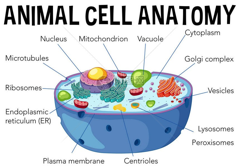

作者正例图 2 · SHA `0cddd9c14620`

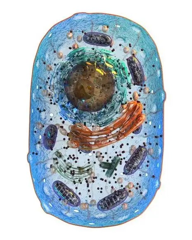

作者正例图 3 · SHA `601169c59b5b`

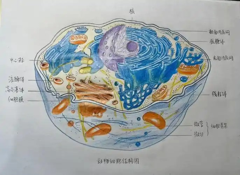

作者正例图 4 · SHA `a25ef497c5f8`

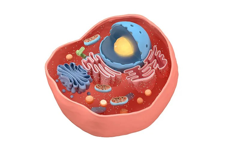

作者正例图 5 · SHA `a9b66d649163`

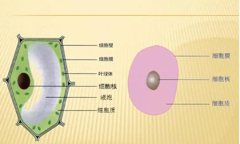

## 25. 偏光显微镜
分类桶：人工器物与饮食制品 / 实验与显微观测仪器；审核正例：6 张

**原概念分类：** 3 · 有视觉特征但需要专业支持才了解

定义：偏光显微镜是一类利用起偏器和检偏器等偏振光学组件，对样品的光学各向异性、双折射或相关偏振性质进行观察和分析的光学显微镜。其范围包括透射偏光和反射偏光配置，也包括普通光学显微镜加装必要组件后形成的偏光观察配置，而不限于某个品牌、型号或医疗用途。

### 提供5张作者正例图

状态：**candidate**；

**题面：** 生成一张常规正置透射式偏光显微镜的教学光路示意图，表现空载调校状态：光源开启，无样品，不插入补偿片，起偏器和检偏器均已插入光路，并调至目镜视野最暗。用剖视或展开示意展示两偏振元件相对于载物台、聚光镜、物镜和目镜的位置，并标注元件名称。附沿光轴观察的透振轴方向示意，使两个偏振元件的方向可在共同参照下比较，同时画出对应的目镜视野。

,考点,依据,可观察判据
0,透射偏光显微镜中起偏器、样品位置与检偏器的光路关系。,审定材料 E4 所列来源 [Nikon’s MicroscopyU《Polarized Light Microscopy》](https://www.microscopyu.com/techniques/polarized-light/polarized-light-microscopy)，本次实际查阅网页的“Figure 1 - Polarized Light Microscope Configuration”段落：起偏器位于光到达样品之前，检偏器位于物镜后孔径与观察筒或相机端口之间。此处用于题面限定的常规正置透射配置。,沿光传播方向，起偏器应位于载物台的样品位置之前，检偏器应位于物镜之后、目镜之前，两者实际接入同一照明与观察光路。把两者都放在样品之前、把检偏器放在物镜之前，或仅在镜身旁画出未接入光路的附件，均属结构关系错误。起偏器与聚光镜的具体装配方式不作唯一限制。
1,空载视野消光所需的两偏振元件透振方向关系。,本次另实际查阅审定材料 E4 同源网页 [Nikon’s MicroscopyU《Polarized Light Microscopy》](https://www.microscopyu.com/techniques/polarized-light/polarized-light-microscopy) 的“Basic Properties of Polarized Light”部分：起偏器与检偏器的透振方向相互垂直时形成正交配置；空载且无其他改变偏振的元件介入时，观察视野呈暗场。这是网页补充段落的依据，不将其冒称为 E4 指定原文块的内容。,共同参照下的两个透振轴应相互垂直，对应目镜视野应整体近黑；允许实际系统的轻微漏光，不要求像素级纯黑。任意整体旋转后的垂直轴组合均可。透振轴平行或明显斜交却声称达到消光，或以两滤片本体互相垂直代替透振轴正交，均属错误。仅写“消光”而未画出可比较的轴向，不能证明该关系正确。


**Z-Image 作答：** generated 

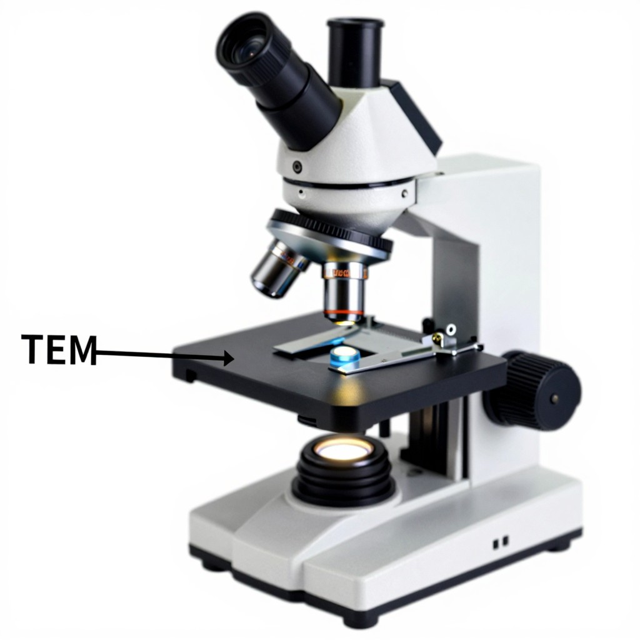

{'task_id': 't2i_d52608d92bfcfaf88b2fbe86d76558a11d0f4175944149b7b890925379241df3',
 '生成模型': 'Z-Image-Turbo',
 'seed': 373478029,
 '图像SHA': '2904564a071a8e8082389231f7304190d1d94e0c5e11216fa8d3fc1eb3221d1c'}

**GPT-6 评审：** reviewed 

{'结论': 'fail',
 '分数（-1=不评分）': 2,
 '原因': '作答仅给出显微镜外观，未提供题面明确要求的透振轴比较图与对应目镜视野，无法完成核心消光关系的教学表达。内部偏振元件的位置因无剖视或展开光路而不可判，但这一限制不改变明确缺少核心示意内容的结论。',
 '依据': '依据常规正置透射偏光显微镜的光路知识：起偏器在样品位置之前，检偏器在物镜之后、目镜之前；空载且无其他改变偏振的元件时，两透振轴正交对应近黑视野。两项判据适用于题面；不由外壳外观推断内部元件存在或缺失，亦不将暗色目镜镜片等同于目镜视野。本次未实际检索网页。',
 '错误类型': 'generic_category',
 '本轮评审建议类别': 3}

,考点编号,判断,像素证据,理由
0,1,inconclusive,图中可见底座上的亮光源、载物台、上方物镜和目镜，但镜身为不透明外观，没有剖视、展开光路或起偏器与检偏器的名称标注；唯一醒目标注为指向载物台附近的“ TEM ”。,这些外观不能显示两偏振元件与样品位置、物镜及目镜之间的先后关系，无法确认它们是否实际接入同一光路；也不能据此认定内部没有这些元件。
1,2,fail,完整画面仅呈现显微镜外观及一个文字箭头，没有沿光轴观察的两个透振轴方向图，也没有单独展示对应的目镜视野；左上方目镜仅显示斜视的镜片表面。,题面明确要求画出共同参照下可比较的轴向和相应视野，这些核心示意内容在完整画面中缺失。失败在于未表达要求核对的关系，而不是从不可见的内部构造断言两轴不正交。


{'knowledge_level': 'specialist',
 'common_cn': 'no',
 'visual_support': 'strong',
 'confidence': 'high',
 'reason': '本题需要核对偏振元件在显微光路中的具体位置，以及透振轴正交与空载消光的对应关系，属于专业光学结构知识，而非一般显微镜外观识别。通过标注明确的展开光路、共同参照轴向图及视野图，可以直接核对这些要求。',
 'caveat': '起偏器与聚光镜的具体装配可有合法变化；透振轴整体旋转不影响正交关系，轻微漏光也不必判错。仅凭完整仪器外观不能确认内部配置。',
 'sources': []}

{'生成固定快照': {'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/probe_generations__ready_positive20_taxonomyv8_codex_v16_probe_20261004.lance',
  'version': 6},
 '评审快照': {'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/probe_reviews__ready_positive20_taxonomyv8_codex_v16_probe_20261004.lance',
  'version': 19}}

{'runtime': 'codex',
 '记录轮次或会话数': 1,
 '算子观察数': 0,
 '结果版本': {'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/designs__ready_positive20_taxonomyv8_codex_v16_probe_20261004.lance',
  'version': 21},
 '复用': False}

{'原生检索次数': 1,
 '完整会话日志': {'journal_path': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/calls__ready_positive20_taxonomyv8_codex_v16_probe_20261004.sqlite',
  'request_id': 'c5ebfce4388ce768601459144dd3b8dbe4871d762431ba046142c5c7c83ad3dd',
  'kind': 'response'}}

### 固定名单绑定的作者正例（实际发送是否成功见设计状态）

作者正例图 1 · SHA `ef85882b397d`

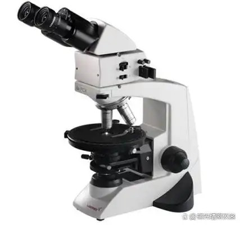

作者正例图 2 · SHA `fcd30480f678`

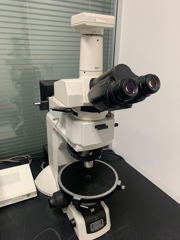

作者正例图 3 · SHA `a6a12fbea1cb`

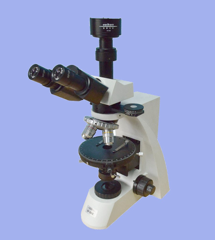

作者正例图 4 · SHA `68c793306a2f`

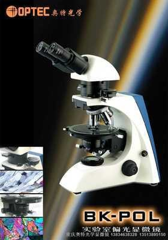

作者正例图 5 · SHA `0cc7e621c9e1`

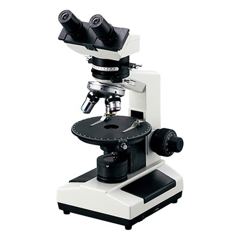

In [1]:
# 第2格：独立只读查看；不依赖第1格，不调用模型、不写业务表。修改PAGE后重跑本格。
import base64
import io
import json
import os
import re
import sys
from html import escape
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo
import lance
import pandas as pd
pd.set_option('display.max_colwidth', None)
from PIL import Image as PILImage
from IPython.display import display, Markdown, HTML

PROJECT = Path('/yzp/zhaozy/yangzepeng/0905/demiwtg')
DATA_ROOT = PROJECT.parent
for path in (PROJECT, DATA_ROOT / 'demiflow'):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))
os.environ['DEMIWTG_DATASETS_ROOT'] = str(DATA_ROOT)
from demiflow import data
from demiflow.operator_llm.call_ref import read_call
from demiflow.operator_llm.sqlite_journal import SQLitePromptJournal
from benchmark.t2i.v2.operaters.run_tables import RunTables
from benchmark.t2i.v2.operaters.images import positive_image_data_url

# 独立查看300个新名单及全部169个原第一类概念的审核/正例覆盖；分页只读。
SELECTION_RUN_ID = 'ready_positive300_common100_priority_20261004'
COMMON_PAGE = 0
COMMON_PAGE_SIZE = 20
selection_dir = PROJECT / 'benchmark/t2i/v2/runs' / SELECTION_RUN_ID
selection_state = RunTables(DATA_ROOT, 'demiwtg/benchmark/t2i/v2/datasets/records__' + SELECTION_RUN_ID + '.lance').load()
coverage = json.loads((selection_dir / 'category1_audit.json').read_text())
common_scope = pd.DataFrame(coverage['records'])
selected_names = set()
if selection_state and selection_state.get('inputs'):
    selected_names = {row['concept'] for row in data.read_lance(**selection_state['inputs'], columns=['concept']).take_all()}
    revision = selection_state['selection']['revision']
    display(Markdown(f"**300个名单已修订**：第一类目标 {revision['requested_common_count']} 个，实际 {revision['selected_common_count']} 个；新增 {len(revision['added'])} 个，替换 {len(revision['removed'])} 个。当前只提交名单，尚未启动本300项出题。"))
    display({'新名单固定版本':selection_state['inputs'], '分类挂载待补':revision.get('unassigned_common_taxonomy', []), '第一类正例下限':revision['min_common_positive_images'],
             '待补至目标':revision['requested_common_count'] - revision['selected_common_count'],
             '技术原因排除的参考图':revision.get('image_exclusions', [])})
    pixel_verification_path = selection_dir / 'sampling_verification.json'
    if pixel_verification_path.exists():
        pixel_verification = json.loads(pixel_verification_path.read_text())
        if pixel_verification['cohort'] == selection_state['inputs']:
            display({'已检查参考图关系':pixel_verification['common_reference_relations_checked'],
                     '技术失败':pixel_verification['common_reference_failures']})
    display(HTML('<details><summary>新增与替换的概念</summary><pre>' + escape(json.dumps(
        {'新增':revision['added'], '移出':revision['removed']}, ensure_ascii=False, indent=2)) + '</pre></details>'))
# 300项原分类与正例数量另行分页，不混入下方20项的作答结果。
COHORT_PAGE = 0
COHORT_PAGE_SIZE = 20
if selection_state and selection_state.get('inputs'):
    cohort_table = pd.DataFrame(data.read_lance(**selection_state['inputs'], columns=[
        'concept','selection_rank','positive_image_count','sampling_category']).take_all()).sort_values('selection_rank')
    cohort_labels = {name:set() for name in cohort_table.concept}
    predicate = 'concept IN (' + ','.join("'" + name.replace("'", "''") + "'" for name in cohort_labels) + ')'
    for source in coverage['category_sources']:
        cols = ['concept','final_category'] + (['final_selected'] if source['kind'] == 'adjudications' else [])
        for record in data.read_lance(**source['result'], columns=cols, filter=predicate).take_all():
            if record.get('final_selected', True) and record['final_category'] in ('1','2','3'):
                cohort_labels[record['concept']].add(record['final_category'])
    cohort_table['原分类'] = cohort_table.concept.map(lambda name:' / '.join(sorted(cohort_labels[name])))
    display(cohort_table.groupby('原分类').size().rename('概念数').to_frame())
    assert COHORT_PAGE >= 0 and 1 <= COHORT_PAGE_SIZE <= 100
    display(cohort_table[['selection_rank','concept','原分类','positive_image_count','sampling_category']].iloc[
        COHORT_PAGE * COHORT_PAGE_SIZE:(COHORT_PAGE + 1) * COHORT_PAGE_SIZE])
common_scope['已纳入300'] = common_scope.concept.isin(selected_names)
common_scope['原分类'] = common_scope.original_categories.map(lambda records: ' / '.join(sorted({r['final_category'] for r in records if r.get('final_selected', True)})))
display(Markdown(f"原第一类范围 **{coverage['scope_count']}**；概念审核通过可出题 **{coverage['ready_count']}**；至少1张正例 **{coverage['ready_at_least_one']}**；至少5张 **{coverage['eligible_count']}**。正例按相同审定、审核match且aligned、SHA去重、冲突排除统计；原分类冲突保留。"))
assert COMMON_PAGE >= 0 and 1 <= COMMON_PAGE_SIZE <= 100
display(common_scope[['concept','原分类','status','identity_status','task_status','positive_image_count','已纳入300']].iloc[
    COMMON_PAGE * COMMON_PAGE_SIZE:(COMMON_PAGE + 1) * COMMON_PAGE_SIZE].rename(columns={
    'concept':'概念','status':'概念审核状态','identity_status':'身份状态','task_status':'出题资格','positive_image_count':'审核正例数'}))

RUN_ID = 'ready_positive20_taxonomyv8_codex_v16_probe_20261004'
PAGE = 0
PAGE_SIZE = 3
LIVE_PAGE = 0  # 已返回响应按请求提交时间倒序分页；与下方固定名单的PAGE独立。
LIVE_PAGE_SIZE = 3
CONCEPT = ''  # 填精确概念名可直接定位；为空时按固定selection_rank分页。
OWNER = Path('demiwtg/benchmark/t2i/v2/datasets')
RUN_CONFIGURATION = json.loads((PROJECT / 'benchmark/t2i/v2/runs' / RUN_ID / 'config.json').read_text())
VARIANTS = RUN_CONFIGURATION.get('authoring_variants') or [RUN_CONFIGURATION['authoring_variant']]
PAIRED = bool(RUN_CONFIGURATION.get('authoring_variants'))
PROCESS_PATH = PROJECT / 'benchmark/t2i/v2/runs' / RUN_ID / 'process.json'
if PROCESS_PATH.exists():
    process = json.loads(PROCESS_PATH.read_text())
    proc = Path('/proc') / str(process['pid'])
    alive = proc.exists() and process.get('process_start_ticks') == proc.joinpath('stat').read_text().rsplit(')', 1)[1].split()[19]
    display({'后台进程':process['pid'], '进程仍存在':alive, '启动时间（北京时间）':datetime.fromisoformat(process['started_at']).astimezone(ZoneInfo('Asia/Shanghai')).isoformat(), '日志':process['log']})
    with Path(process['log']).open('rb') as output:
        output.seek(max(0, output.seek(0, 2) - 16000))
        log_tail = output.read().decode('utf-8', errors='replace')
    display(HTML('<details><summary>后台日志末尾（最多16 KB）</summary><pre>' + escape(log_tail) + '</pre></details>'))
state = RunTables(DATA_ROOT, str(OWNER / f'records__{RUN_ID}.lance')).load()
state = state or {'complete':False, 'phase':'not_started'}
COHORT_REF = RUN_CONFIGURATION.get('cohort_source') or state.get('inputs')
# 固定名单与本轮输入分别显示；等待/失败项始终保留在20概念分母里。
display({'刷新时间（北京时间）':datetime.now(ZoneInfo('Asia/Shanghai')).isoformat(),
         '本轮配置':RUN_CONFIGURATION, '本轮已提交输入':state.get('inputs')})
assert PAGE >= 0 and LIVE_PAGE >= 0 and 1 <= PAGE_SIZE <= 20 and 1 <= LIVE_PAGE_SIZE <= 20
if not COHORT_REF:
    display(Markdown('当前运行尚未提交共同输入；旧输出不能作为本轮完成结果。'))
else:
    display(Markdown(f"## 出题运行：{RUN_ID}\n阶段：{state.get('phase')}；全部完成：{state['complete']}。候选题仍待质量审核。"))
    display({'固定概念名单': COHORT_REF})
    narrow = data.read_lance(**COHORT_REF, columns=['concept','selection_rank','positive_image_count','sampling_category']).take_all()
    summary = pd.DataFrame(narrow).sort_values('selection_rank')
    summary['一级分类'] = summary.sampling_category.str.split(' / ').str[0]
    display(summary.groupby('一级分类', sort=True).size().rename('概念数').to_frame())
    display(Markdown(f"共同名单 {len(summary)} 个；最少审核正例 {summary.positive_image_count.min()} 张。按本轮固定分类路径抽样；分类来源和质量状态见下方。"))
    taxonomy = state.get('sources', {}).get('sampling_taxonomy')
    if taxonomy:
        display({'分类版本':taxonomy['summary'], '分类运行':taxonomy['run'],
                 '分类阶段':taxonomy['phase'], '分类质量通过':taxonomy['quality_passed'],
                 '满足图数门槛':state['selection']['ready_with_positive_images'],
                 '因未匹配分类排除':state['selection']['excluded_without_matching_taxonomy']})
        if not taxonomy['quality_passed']:
            display(Markdown('本轮仅以候选分类进行分层抽样，不代表该分类已发布或全部复核通过。'))
    else:
        display(Markdown('沿用固定输入表保存的分类。当前只执行配置中的版本，达到本批概念数后停止。'))
    # 原概念三类来自evaluation/t2i/case_annotation已提交的历史结果；仅只读关联，不进入模型请求。
    from evaluation.t2i.case_annotation.operaters.review import FINAL_CATEGORIES
    CATEGORY_SOURCES_PATH = PROJECT / 'benchmark/t2i/v2/runs' / RUN_ID / 'case_category_sources.json'
    category_sources = json.loads(CATEGORY_SOURCES_PATH.read_text()) if CATEGORY_SOURCES_PATH.exists() else []
    original_categories = {name:[] for name in summary.concept}
    category_predicate = 'concept IN (' + ','.join("'" + name.replace("'", "''") + "'" for name in summary.concept) + ')'
    for category_source in category_sources:
        kind = category_source['kind']
        reason_column = 'classification_reason' if kind == 'classifications' else 'adjudication_reason'
        category_columns = ['concept','id','image_sha256','final_category',reason_column]
        if kind == 'adjudications':
            category_columns.append('final_selected')
        # 按原概念名精确匹配，只读固定20项所需列，历史URI由平台迁移映射解析。
        for category_row in data.read_lance(**category_source['result'], columns=category_columns, filter=category_predicate).take_all():
            category_code = category_row['final_category']
            category_label = FINAL_CATEGORIES.get(category_code, '暂缓归类')
            if category_row.get('final_selected') is False:
                category_label = '原记录未纳入'
            original_categories[category_row['concept']].append({
                '原类别': (str(category_code) + ' · ' if category_code and category_row.get('final_selected') is not False else '') + category_label,
                '来源':category_source['label'], '原归类理由':category_row[reason_column],
                '固定结果':category_source['result'], '固定摘要':category_source['summary'],
                '原case ID':category_row['id'], '原作答图SHA':category_row['image_sha256']})
    original_category_labels = {name:' / '.join(dict.fromkeys(row['原类别'] for row in records)) or '无已配置的原标注'
                                for name, records in original_categories.items()}
    display(Markdown('**原概念分类**：①常见但容易错；②有显著的视觉特征；③有视觉特征但需要专业支持才了解。读取已有标注，详情保留全部来源；本轮作答评审建议另列。'))
    display({'原分类固定来源':category_sources,
             '已关联原分类的概念数':sum(bool(records) for records in original_categories.values()), '本轮概念数':len(summary)})
    probe_views = {}
    for variant in VARIANTS:
        branch = RunTables(DATA_ROOT, str(OWNER / f'records__{RUN_ID}__{variant}.lance')).load() if PAIRED else state
        display(Markdown('### ' + ('提供正例图' if variant == 'with_positive_images' else '不提供正例图')))
        branch_id = RUN_ID + '__' + variant if PAIRED else RUN_ID
        # 运行中只读本次writer已经提交的新版本；旧运行的head不得冒充本轮结果。
        probe = (branch or {}).get('probe') or {}
        probe_refs = dict(probe.get('outputs', {}))
        if branch and branch.get('phase') == 'probing':
            for stage, uri in probe.get('stage_uris', {}).items():
                if Path(uri).exists():
                    head = lance.dataset(uri).version
                    if head > probe.get('start_versions', {}).get(stage, head):
                        probe_refs[stage] = {'uri':uri, 'version':head}
        probe_views[variant] = probe_refs
        if probe:
            probe_progress = {}
            for stage in ('designs', 'candidates', 'generations', 'reviews'):
                if stage in probe_refs:
                    snapshot = lance.dataset(probe_refs[stage]['uri'], version=probe_refs[stage]['version'])
                    probe_progress[stage] = {'已提交行数':snapshot.count_rows(), '快照':probe_refs[stage]}
                    if stage == 'generations':
                        probe_progress[stage]['成功'] = snapshot.count_rows(filter="status = 'generated'")
                    if stage == 'reviews':
                        probe_progress[stage]['已评审'] = snapshot.count_rows(filter="review_status = 'reviewed'")
            display({'逐题探测':probe_progress, '评审模型':probe['review_model'],
                     '推理强度':probe.get('review_reasoning_effort'), '预算':probe['settings']})
        else:
            display(Markdown('本轮尚未提交探测阶段摘要；当前through=' + RUN_CONFIGURATION.get('through', 'author') + '。'))
        # 只投影20概念的状态和原因；各表版本在本次刷新时固定，明细也使用这些引用。
        progress = summary[['selection_rank','concept']].copy()
        progress['原分类'] = progress.concept.map(original_category_labels)
        design_rows = data.read_lance(**probe_refs['designs'], columns=['concept','status','reason']).take_all() if 'designs' in probe_refs else []
        generation_rows = data.read_lance(**probe_refs['generations'], columns=['concept','status','reason']).take_all() if 'generations' in probe_refs else []
        review_rows = data.read_lance(**probe_refs['reviews'], columns=['concept','review_status','review_reason']).take_all() if 'reviews' in probe_refs else []
        design_by_name = {row['concept']:row for row in design_rows}
        generation_by_name = {row['concept']:row for row in generation_rows}
        review_by_name = {row['concept']:row for row in review_rows}
        progress['出题'] = [design_by_name.get(name, {}).get('status', '等待/进行中') for name in progress.concept]
        progress['生图'] = [generation_by_name.get(name, {}).get('status',
            '待生图' if design_by_name.get(name, {}).get('status') == 'candidate' else
            '跳过' if name in design_by_name else '等待出题') for name in progress.concept]
        progress['评审'] = [review_by_name.get(name, {}).get('review_status',
            '待评审' if generation_by_name.get(name, {}).get('status') == 'generated' else
            '等待跳过记录' if name in generation_by_name else
            '跳过' if name in design_by_name and design_by_name[name]['status'] != 'candidate' else '等待生图') for name in progress.concept]
        progress['原因'] = ['；'.join(filter(None, [design_by_name.get(name, {}).get('reason'),
            generation_by_name.get(name, {}).get('reason'), review_by_name.get(name, {}).get('review_reason')])) for name in progress.concept]
        display(Markdown(f'**逐概念进度（固定 {len(summary)} 项）**：阶段尚无提交时显示等待/进行中；进程退出不表示成功。'))
        display(progress.rename(columns={'selection_rank':'原抽样顺序','concept':'概念'}).set_index('原抽样顺序'))
        display({'设计已提交':len(design_rows), '生图已提交':len(generation_rows), '评审已提交':len(review_rows),
                 '固定概念总数':len(summary), '本次刷新快照':probe_refs})
        journal_path = DATA_ROOT / OWNER / f'calls__{branch_id}.sqlite'
        stats = {'requests':0, 'responses':0, 'saved_errors':0, 'without_response_or_error':0}
        live = []
        if journal_path.exists():
            reader = SQLitePromptJournal(journal_path, read_only=True)
            try:
                stats = reader.inspection_stats()
                live = reader.call_page(offset=LIVE_PAGE*LIVE_PAGE_SIZE, limit=LIVE_PAGE_SIZE,
                    max_record_bytes=8*1024*1024, max_page_bytes=24*1024*1024)
            finally:
                reader.close()
        display({'全部提交完成':bool(branch and branch.get('complete')), '正式结果计数':(branch or {}).get('counts',{}),
                 '本版任务数':len(summary), '已提交会话':stats['requests'], '已保存响应':stats['responses'],
                 '调用失败':stats['saved_errors'], '等待响应或状态未知':stats['without_response_or_error'],
                 '无会话记录（含调用前失败）':max(0, len(summary)-stats['requests'])})
        display(Markdown('**运行中题目预览**：只读已保存响应；probe模式逐题提交设计、生图和评审，正式状态以下方结果表为准。'
                         + f' 当前响应页 {LIVE_PAGE}，每页 {LIVE_PAGE_SIZE} 条；修改 LIVE_PAGE 后重跑本格。'))
        if not live:
            display(Markdown('本页尚无已返回响应。'))
        for record in live:
            if record.get('omitted'):
                display({'请求':record['request_id'], '预览未解码':record['omitted'], '字节':record.get('stored_bytes')})
                continue
            request = record.get('request') or {}
            response = record.get('response') or {}
            # 请求中的实际业务JSON保存于文本part；不读取图片字节或重新渲染prompt。
            texts = []
            for message in request.get('messages', []):
                content = message.get('content', '')
                texts.extend([content] if isinstance(content, str) else [part.get('text', '') for part in content if isinstance(part, dict)])
            matches = re.findall(r'"concept"\s*:\s*("(?:[^"\\]|\\.)*")', '\n'.join(texts))
            concept = json.loads(matches[-1]) if matches else record['request_id'][:12]
            display(Markdown('#### ' + concept))
            display(Markdown('**原概念分类：** ' + original_category_labels.get(concept, '请按固定名单查看原分类')))
            display({'会话状态':response.get('status'), '耗时秒':round(response.get('elapsed_s', 0), 1),
                     '原生检索次数':response.get('native_searches', 0), '请求ID':record['request_id']})
            result = (response.get('content') or {}).get('result', {})
            question = result.get('question')
            if isinstance(question, dict):
                display(Markdown('**题面：** ' + question.get('instruction', '')))
                display(pd.DataFrame(question.get('test_points', [])).rename(columns={'point':'考点','basis':'依据','criterion':'可观察判据'}))
            else:
                display(Markdown('**未出题：** ' + result.get('reason', '响应没有可预览的题目，请查看原始响应或错误。')))
            display(HTML('<details><summary>完整响应内容</summary><pre>' + escape(json.dumps(response.get('content'), ensure_ascii=False, indent=2)) + '</pre></details>'))
    names = ([CONCEPT] if CONCEPT else summary.iloc[PAGE*PAGE_SIZE:(PAGE+1)*PAGE_SIZE].concept.tolist())
    pd.set_option('display.max_colwidth', None)
    for name in names:
        quoted = "'" + name.replace("'", "''") + "'"
        cohort = data.read_lance(**COHORT_REF, filter='concept = ' + quoted).take(1)
        if not cohort:
            display(Markdown('本轮没有该概念：' + name))
            continue
        item = cohort[0]
        display(Markdown(f"## {item['selection_rank']}. {name}\n分类桶：{item['sampling_category']}；审核正例：{item['positive_image_count']} 张"))
        display(Markdown('**原概念分类：** ' + original_category_labels[name]))
        display(HTML('<details><summary>原分类理由与固定来源</summary><pre>'
            + escape(json.dumps(original_categories[name], ensure_ascii=False, indent=2)) + '</pre></details>'))
        display(Markdown('定义：' + item['concept_record']['definition']))
        for variant in VARIANTS:
            label = '提供5张作者正例图' if variant == 'with_positive_images' else '不给作者正例图'
            display(Markdown('### ' + label))
            branch = RunTables(DATA_ROOT, str(OWNER / f'records__{RUN_ID}__{variant}.lance')).load() if PAIRED else state
            if branch and 'designs' in probe_views.get(variant, {}):
                branch = {**branch, 'designs':probe_views[variant]['designs']}
            if not branch or not branch.get('designs'):
                display(Markdown('该版本尚未提交设计表；可先看上方运行中题目预览。日志响应数量不等于正式题目交付数。'))
                continue
            cases = data.read_lance(**branch['designs'], filter='concept = ' + quoted).take(2)
            if len(cases) != 1:
                display(Markdown('该概念尚未提交设计结果。' if not cases else '该概念存在重复结果，须检查。'))
                continue
            case = cases[0]
            display(Markdown('状态：**' + case['status'] + '**；' + (case['reason'] or '')))
            if case['question']:
                display(Markdown('**题面：** ' + case['question']['instruction']))
                display(pd.DataFrame(case['question']['test_points']).rename(columns={'point':'考点','basis':'依据','criterion':'可观察判据'}))
            refs = probe_views.get(variant, {})
            if refs:
                generated = data.read_lance(**refs['generations'], filter='concept = ' + quoted).take(1) if 'generations' in refs else []
                reviewed = data.read_lance(**refs['reviews'], filter='concept = ' + quoted).take(1) if 'reviews' in refs else []
                if generated:
                    answer = generated[0]
                    display(Markdown('**Z-Image 作答：** ' + answer['status'] + ' ' + answer['reason']))
                    if answer['object_ref']:
                        try:
                            encoded = positive_image_data_url(answer['object_ref'])
                            with PILImage.open(io.BytesIO(base64.b64decode(encoded.split(',',1)[1]))) as picture:
                                picture.thumbnail((640,640))
                                display(picture.copy())
                        except (OSError, ValueError) as error:
                            display(Markdown('作答图无法读取：' + str(error)))
                    display({'task_id':answer['task_id'], '生成模型':answer['model'], 'seed':answer['seed'], '图像SHA':answer['image_sha256']})
                elif case['question']:
                    display(Markdown('本题尚未提交生图结果。'))
                if reviewed:
                    judged = reviewed[0]
                    display(Markdown('**GPT-6 评审：** ' + judged['review_status'] + ' ' + judged['review_reason']))
                    if judged['review']:
                        review = judged['review']
                        display({'结论':review['verdict'], '分数（-1=不评分）':review['score'], '原因':review['reason'],
                                 '依据':review['basis'], '错误类型':review['failure_type'], '本轮评审建议类别':judged['case_category']})
                        display(pd.DataFrame(review['point_results']).rename(columns={'index':'考点编号','verdict':'判断','evidence':'像素证据','reason':'理由'}))
                        display(review['case_annotation'])
                    display({'生成固定快照':judged['generation_source'], '评审快照':refs['reviews']})
                    display(HTML('<details><summary>评审调用信息与完整错误</summary><pre>'
                        + escape(judged.get('review_call_json') or '{}') + '</pre></details>'))
                elif generated:
                    display(Markdown('本题尚未提交评审结果。'))
            if case.get('reasoning'):
                display(HTML('<details><summary>模型返回的 reasoning</summary><pre>' + escape(case['reasoning']) + '</pre></details>'))
            call = json.loads(case['call_json'])
            history = json.loads(case['authoring_context_json'])
            display({'runtime':call.get('runtime', 'demiflow'), '记录轮次或会话数':len(call.get('environment',{}).get('turns',[])), '算子观察数':len(history),
                     '结果版本':branch['designs'], '复用':call.get('reused')})
            if history:
                display(HTML('<details><summary>完整算子调用、错误反馈与补读原文</summary><pre>' + escape(json.dumps(history, ensure_ascii=False, indent=2)) + '</pre></details>'))
            if call.get('runtime') == 'codex' and call.get('response_ref'):
                saved = read_call(call['response_ref'], DATA_ROOT)
                native = [event for event in saved.get('events', [])
                          if event.get('method') == 'item/completed'
                          and event.get('params', {}).get('item', {}).get('type') in ('commandExecution', 'webSearch')]
                display({'原生检索次数':call.get('native_searches', 0), '完整会话日志':call['response_ref']})
                if native:
                    display(HTML('<details><summary>Codex 文件读取与网络检索记录</summary><pre>'
                        + escape(json.dumps(native, ensure_ascii=False, indent=2)) + '</pre></details>'))
        display(Markdown('### 固定名单绑定的作者正例（实际发送是否成功见设计状态）'))
        for index, image in enumerate(item['positive_images'], 1):
            try:
                encoded = positive_image_data_url({'uri':image['image_uri'],'sha256':image['sha256']})
                with PILImage.open(io.BytesIO(base64.b64decode(encoded.split(',',1)[1]))) as picture:
                    picture.thumbnail((240,240))
                    display(Markdown(f"作者正例图 {index} · SHA `{image['sha256'][:12]}`"))
                    display(picture.copy())
            except (OSError, ValueError) as error:
                display(Markdown('预览失败：' + str(error)))
